# Doubly Asymptotic Performance Trends

Analyses estimator behaviour for increasing $p$ and $n$ on parameter reconstruction error, chosen lambda, and number of iterations / computation time. Produces Figure 2 of the paper.

For fixed $p$, random prediction problems are generated via: 
$$
\begin{aligned}
\mu &\sim \mathrm{N}(0, I_p)\\
\Sigma &\sim \mathrm{Wishart}(p, I_p)\\
\beta &\sim \mathrm{N}(0, I_p)\\
\varepsilon &\sim \mathrm{N}(0, 0.25)\\
\end{aligned}
$$ 

Then for a designated number of repetitions, training datasets are drawn via $n$ iid samples following:
$$
\begin{aligned}
x &\sim \mathrm{N}(\mu, \Sigma)\\
y \, \mid \, x, \epsilon &\sim \mathrm{N}(x^\mathrm{T}\beta, \epsilon)
\end{aligned}
$$ 


## Preview Experiment

In [1]:
import numpy as np
import problems
from experiments import Experiment, parameter_mean_squared_error, regularization_parameter, number_of_iterations, fitting_time
from matplotlib import pyplot as plt
from plotting import plot_metrics
from fastridge import RidgeEM, RidgeLOOCV

ps = [100, 200]
rng = np.random.default_rng(1)
probs = [problems.random_problem(p, rng=rng) for p in ps]
ns = [100, 200, 300, 400, 500]

ridgeEM = RidgeEM(fit_intercept=False)
ridgeCV_GLM = RidgeLOOCV(alphas=100, fit_intercept=False)
ridgeCV_fixed = RidgeLOOCV(alphas=np.logspace(-10, 10, 100, endpoint=True, base=10), fit_intercept=False)

estimators = [ridgeEM, ridgeCV_fixed, ridgeCV_GLM]
est_names = ['EM', 'CV_fix', 'CV_glm']

exp0 = Experiment(probs, estimators, ns, 10, est_names, seed=1)
exp0.run()

<div><progress max="10" value="10"></progress> 100.00% [10/10 00:02&lt;00:00]</div>

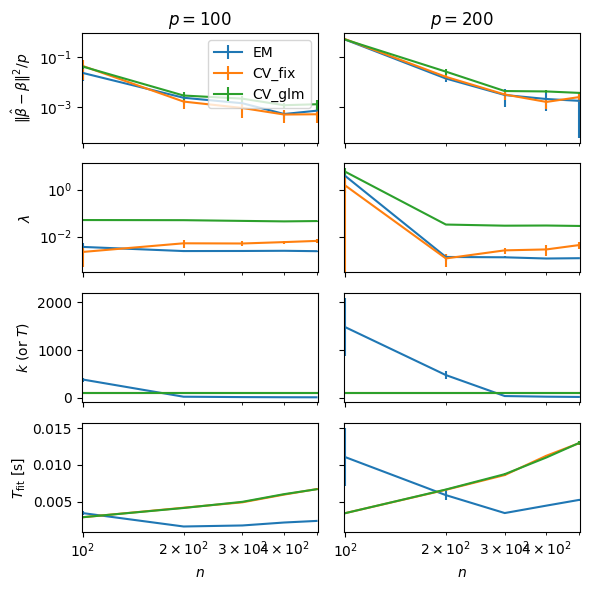

In [2]:
prob_idx = [0, 1]
fig, axs = plot_metrics(exp0, [parameter_mean_squared_error, regularization_parameter, number_of_iterations, fitting_time], prob_idx=prob_idx, figsize=(6, 6))
axs[0, 0].set_yscale('log')
axs[1, 0].set_yscale('log')
axs[1, 0].set_xscale('log')
axs[2, 0].set_ylabel('$k$ (or $T$)')
for i in range(len(prob_idx)):
    axs[0, i].set_title(f'$p={ps[prob_idx[i]]}$')
axs[0, 0].legend()
plt.show()

## Full Experiment

In [3]:
ps1 = [50, 100, 200, 400, 800]
rng1 = np.random.default_rng(1)
probs1 = [problems.random_problem(p, rng=rng1) for p in ps1]
ns1 = [50, 75, 100, 150, 200, 300, 400, 600, 800, 1200, 1600]

exp1 = Experiment(probs1, estimators, ns1, 100, est_names, seed=1)
exp1.run()

<div><progress max="100" value="100"></progress> 100.00% [100/100 08:09&lt;00:00]</div>

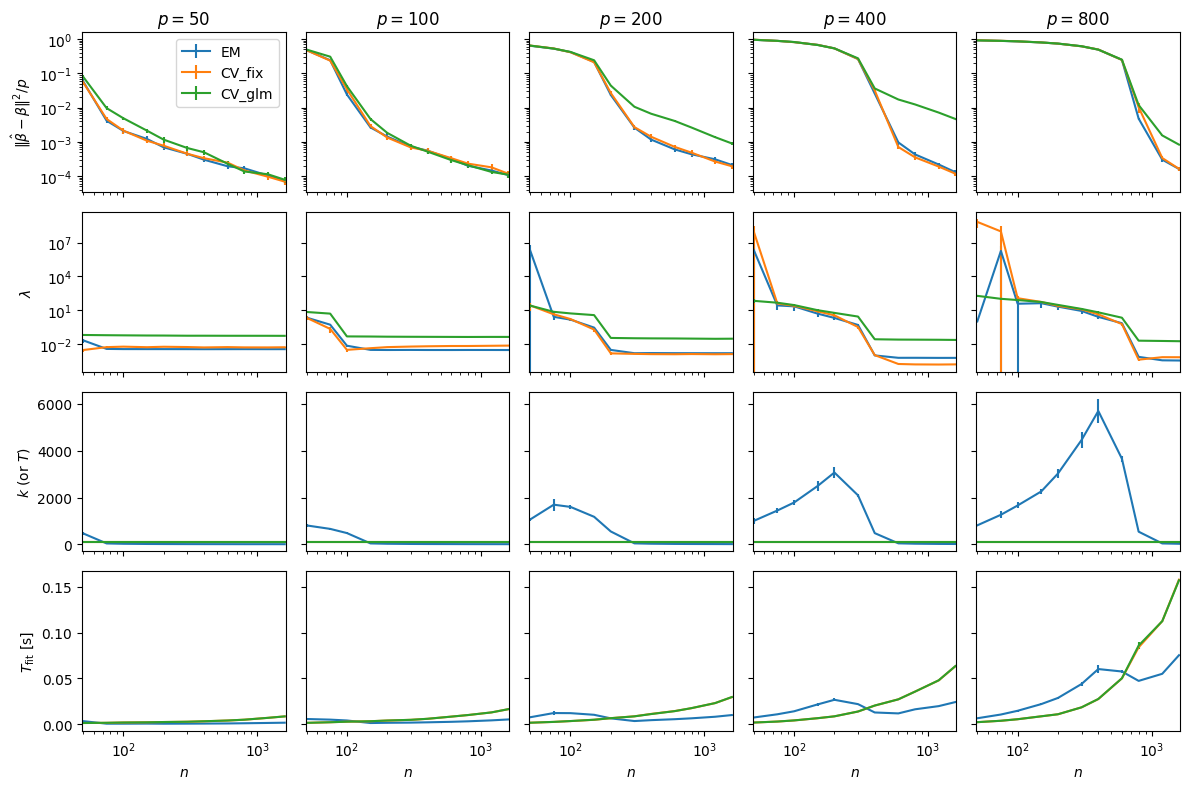

In [5]:
prob_idx1 = [0, 1, 2, 3, 4]
fig, axs = plot_metrics(exp1, [parameter_mean_squared_error, regularization_parameter, number_of_iterations, fitting_time], prob_idx=prob_idx1, figsize=(12, 8))
axs[0, 0].set_yscale('log')
axs[1, 0].set_yscale('log')
axs[1, 0].set_xscale('log')
axs[2, 0].set_ylabel('$k$ (or $T$)')
for i in range(len(prob_idx1)):
    axs[0, i].set_title(f'$p={ps1[prob_idx1[i]]}$')
axs[0, 0].legend()
plt.savefig('../output/paper2023_figure2.pdf', dpi=600, bbox_inches="tight", pad_inches=0)
plt.show()